In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D,MaxPooling2D,Flatten,Dense,Dropout)

from sklearn.metrics import (precision_score,recall_score,f1_score,classification_report)
from sklearn.metrics import confusion_matrix
from openai import OpenAI

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST Dataset Loaded Successfully

Training Data Shape : (60000, 28, 28)
Training Labels Shape : (60000,)

Testing Data Shape : (10000, 28, 28)
Testing Labels Shape : (10000,)
Pixel Values Normalized to [0,1]
Reshaped Training Data : (60000, 28, 28, 1)
Reshaped Testing Data : (10000, 28, 28, 1)


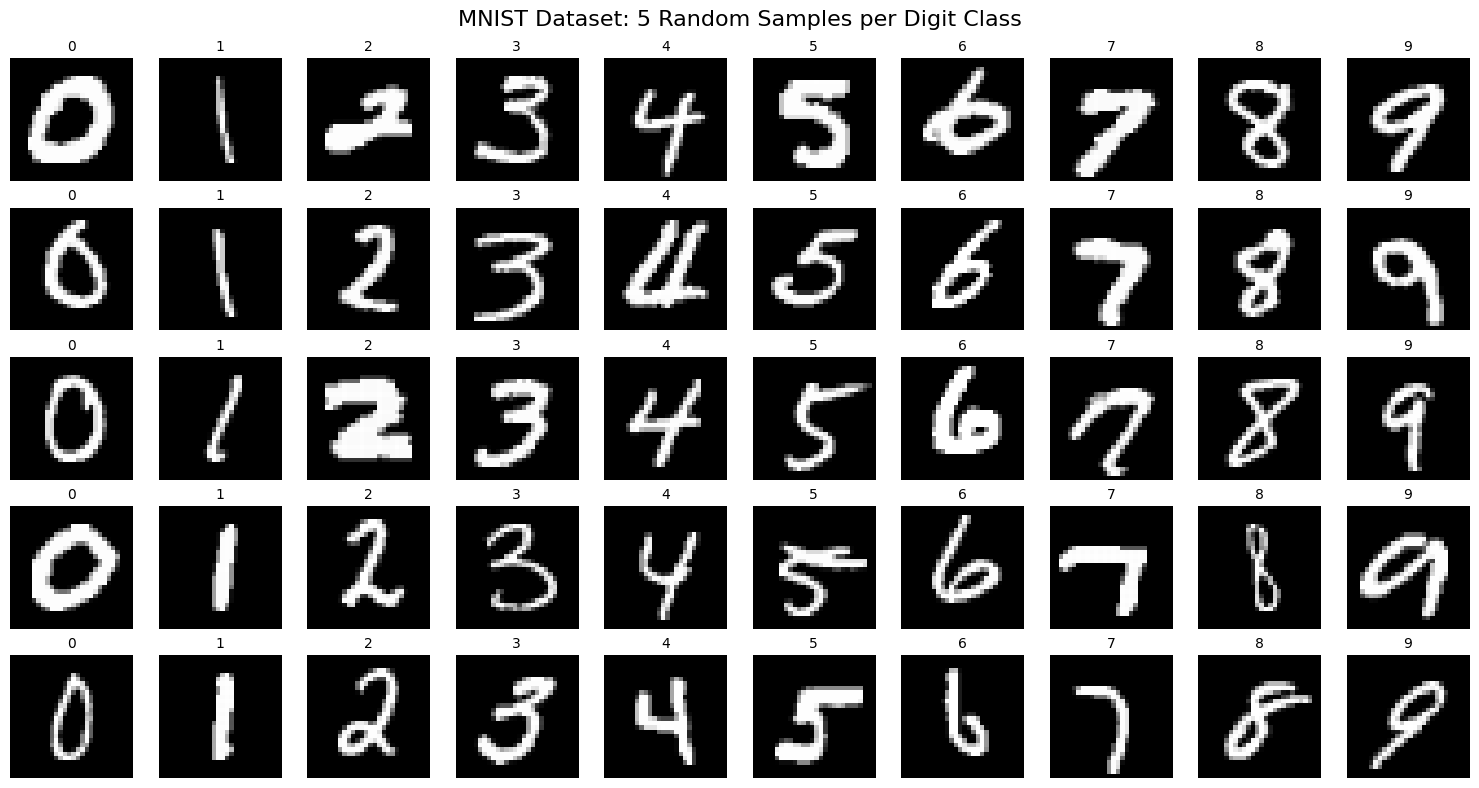

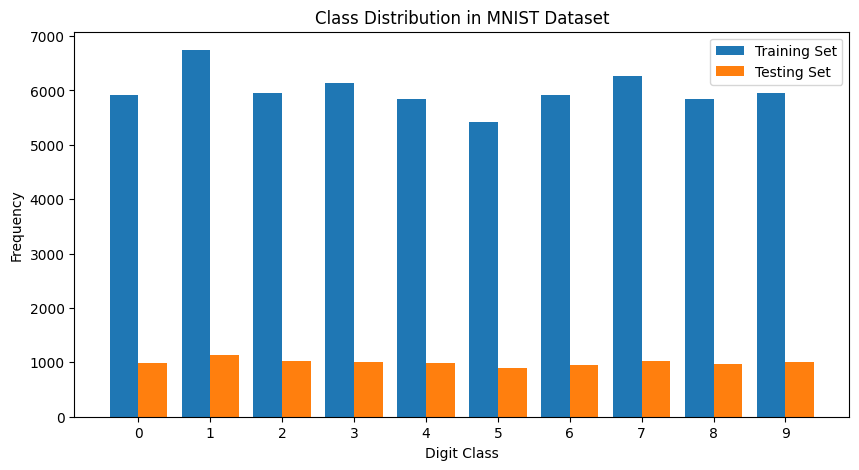


Training Distribution:
[5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]

Testing Distribution:
[ 980 1135 1032 1010  982  892  958 1028  974 1009]

Observation: The MNIST dataset is reasonably balanced across all digit classes.

Number of Images to Augment : 12000
Gaussian Noise Added Successfully


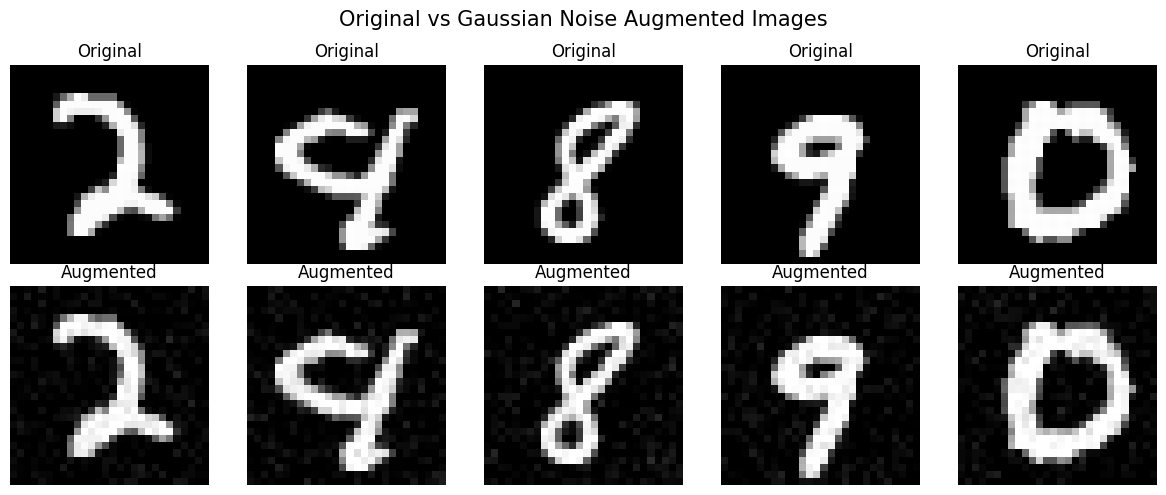

Part 1 Completed Successfully


In [ ]:
# Part 1: Data Preparation and Exploration
np.random.seed(42)
tf.random.set_seed(42)

(X_train_raw, y_train), (X_test_raw, y_test) = keras.datasets.mnist.load_data()       # Load MNIST Dataset
print("MNIST Dataset Loaded Successfully")
print("\nTraining Data Shape :", X_train_raw.shape)
print("Training Labels Shape :", y_train.shape)
print("\nTesting Data Shape :", X_test_raw.shape)
print("Testing Labels Shape :", y_test.shape)

X_train = X_train_raw.astype("float32") / 255.0                                       # Normalize Pixel Values
X_test = X_test_raw.astype("float32") / 255.0
print("Pixel Values Normalized to [0,1]")

X_train = X_train.reshape(-1, 28, 28, 1)                                              # Reshape for CNN Input
X_test = X_test.reshape(-1, 28, 28, 1)
print("Reshaped Training Data :", X_train.shape)
print("Reshaped Testing Data :", X_test.shape)

fig, axes = plt.subplots(nrows=5, ncols=10, figsize=(15,8))                            # Display 5 Random Samples for Each Digit Class
for digit in range(10):
    digit_indices = np.where(y_train == digit)[0]
    random_indices = np.random.choice(digit_indices, size=5, replace=False)

    for row in range(5):
        image = X_train_raw[random_indices[row]]
        axes[row, digit].imshow(image,cmap="gray")

        axes[row, digit].set_title(f"{digit}",fontsize=10)
        axes[row, digit].axis("off")

plt.suptitle("MNIST Dataset: 5 Random Samples per Digit Class",fontsize=16)
plt.tight_layout()
plt.show()


train_counts = np.bincount(y_train)                                                   # Class Distribution
test_counts = np.bincount(y_test)
digits = np.arange(10)
plt.figure(figsize=(10,5))
bar_width = 0.4

plt.bar(digits - bar_width/2,train_counts,width=bar_width,label="Training Set")
plt.bar(digits + bar_width/2,test_counts,width=bar_width,label="Testing Set")

plt.xlabel("Digit Class")
plt.ylabel("Frequency")
plt.title("Class Distribution in MNIST Dataset")
plt.xticks(digits)
plt.legend()
plt.show()

print("\nTraining Distribution:")
print(train_counts)
print("\nTesting Distribution:")
print(test_counts)
print("\nObservation: The MNIST dataset is reasonably balanced across all digit classes.")

# Data Augmentation using NumPy Only
# Add Gaussian Noise to 20% of Training Images

X_train_augmented = X_train.copy()
num_augmented = int(0.20 * len(X_train_augmented))
print("\nNumber of Images to Augment :", num_augmented)

aug_indices = np.random.choice(
    len(X_train_augmented),size=num_augmented,replace=False)

noise = np.random.normal(loc=0.0,scale=0.05,size=X_train_augmented[aug_indices].shape)    # Generate Gaussian Noise
X_train_augmented[aug_indices]= (X_train_augmented[aug_indices] + noise)                  # Apply Noise
X_train_augmented = np.clip(X_train_augmented,0,1)                                        # Keep Pixel Values Between 0 and 1

print("Gaussian Noise Added Successfully")


sample_indices = aug_indices[:5]                                                   # 5 Original vs 5 Augmented
fig, axes = plt.subplots(nrows=2,ncols=5,figsize=(12,5))

for i in range(5):
    axes[0, i].imshow(
        X_train[sample_indices[i]].squeeze(),
        cmap="gray"    )
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")

    axes[1, i].imshow(
        X_train_augmented[sample_indices[i]].squeeze(),
        cmap="gray")
    axes[1, i].set_title("Augmented")
    axes[1, i].axis("off")

plt.suptitle("Original vs Gaussian Noise Augmented Images",fontsize=15)
plt.tight_layout()
plt.show()
print("Part 1 Completed Successfully")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN Model Architecture



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

Model Compiled Successfully
Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.9382 - loss: 0.1997 - val_accuracy: 0.9857 - val_loss: 0.0480
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9809 - loss: 0.0615 - val_accuracy: 0.9885 - val_loss: 0.0421
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9870 - loss: 0.0425 - val_accuracy: 0.9915 - val_loss: 0.0339
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9896 - loss: 0.0335 - val_accuracy: 0.9895 - val_loss: 0.0369
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9915 - loss: 0.0261 - val_accuracy: 0.9898 - val_loss: 0.0367
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9924 - loss: 0.0222 - val_accuracy: 0.9897 - val_loss: 0.0383
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9938 - loss: 0.0184 - val_accuracy: 0.9918 - val_loss: 0.0339
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9946 - lo

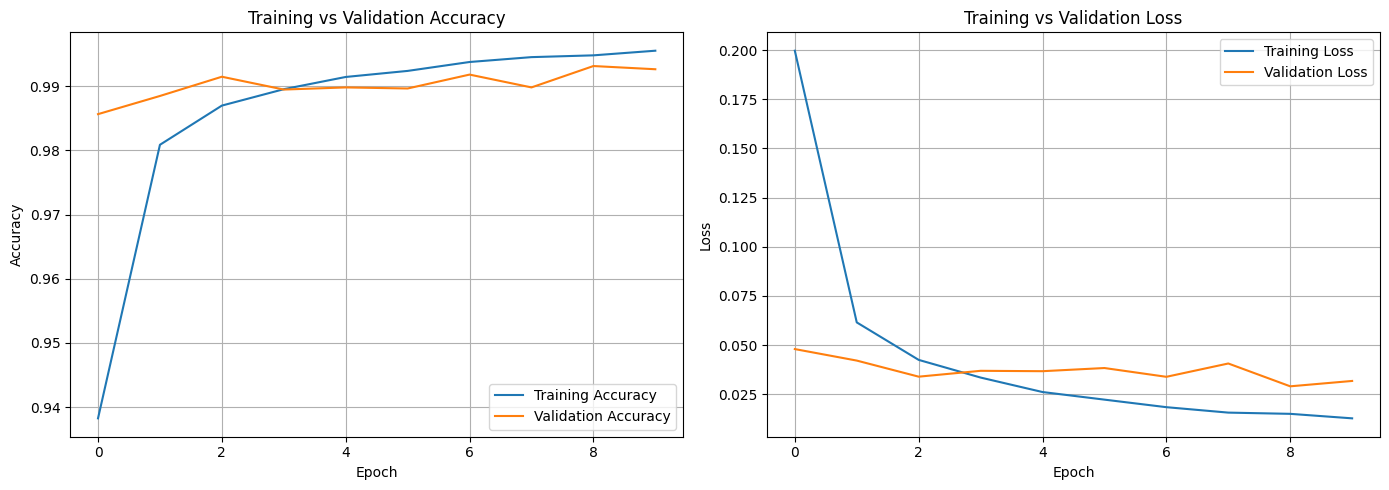

Test Set Performance
Test Accuracy : 0.9931
Test Loss     : 0.0208
Precision, Recall and F1 Score Per Digit
Digit 0 | Precision = 0.9980 | Recall = 0.9980 | F1 = 0.9980
Digit 1 | Precision = 0.9947 | Recall = 0.9982 | F1 = 0.9965
Digit 2 | Precision = 0.9894 | Recall = 0.9981 | F1 = 0.9937
Digit 3 | Precision = 0.9941 | Recall = 0.9950 | F1 = 0.9946
Digit 4 | Precision = 0.9919 | Recall = 0.9939 | F1 = 0.9929
Digit 5 | Precision = 0.9899 | Recall = 0.9933 | F1 = 0.9916
Digit 6 | Precision = 0.9989 | Recall = 0.9854 | F1 = 0.9921
Digit 7 | Precision = 0.9931 | Recall = 0.9864 | F1 = 0.9898
Digit 8 | Precision = 0.9939 | Recall = 0.9959 | F1 = 0.9949
Digit 9 | Precision = 0.9871 | Recall = 0.9861 | F1 = 0.9866
Part 2 Completed Successfully


In [ ]:
# Part 2: CNN Architecture and Training

model = Sequential(
    [Conv2D(filters=32, kernel_size=3, activation='relu', padding='same',
        input_shape=(28,28,1)), MaxPooling2D(pool_size=(2,2)),

    Conv2D(filters=64, kernel_size=3, activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2,2)), Flatten(), Dense(units=128, activation='relu'),
    Dropout(rate=0.3), Dense(units=10, activation='softmax')])                                   # Build CNN Model
print("CNN Model Architecture\n")
model.summary()

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])     # Compile Model
print("Model Compiled Successfully")

history = model.fit(X_train_augmented, y_train, epochs=10, batch_size=64,
                    validation_split=0.10, verbose=1)                                             # Train Model


plt.figure(figsize=(14,5))                                                                        # Plot Training & Validation Curves
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)


plt.subplot(1,2,2)                                                                   # Loss Plot
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)                       # Evaluate Model on Test Data
print("Test Set Performance")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Loss     : {test_loss:.4f}")


y_probabilities = model.predict(X_test, verbose=0)                                         # Predictions
y_predictions = np.argmax(y_probabilities, axis=1)


precision_per_class = precision_score(y_test, y_predictions, average=None)                 # Precision, Recall, F1 Score Per Class
recall_per_class = recall_score(y_test, y_predictions, average=None)
f1_per_class = f1_score(y_test, y_predictions, average=None)
print("Precision, Recall and F1 Score Per Digit")
print("=================================================")
for digit in range(10):
    print(
        f"Digit {digit} | "
        f"Precision = {precision_per_class[digit]:.4f} | "
        f"Recall = {recall_per_class[digit]:.4f} | "
        f"F1 = {f1_per_class[digit]:.4f}")

print("Part 2 Completed Successfully")

Visualizing Learned Filters...
Filter Weight Shape : (3, 3, 1, 32)


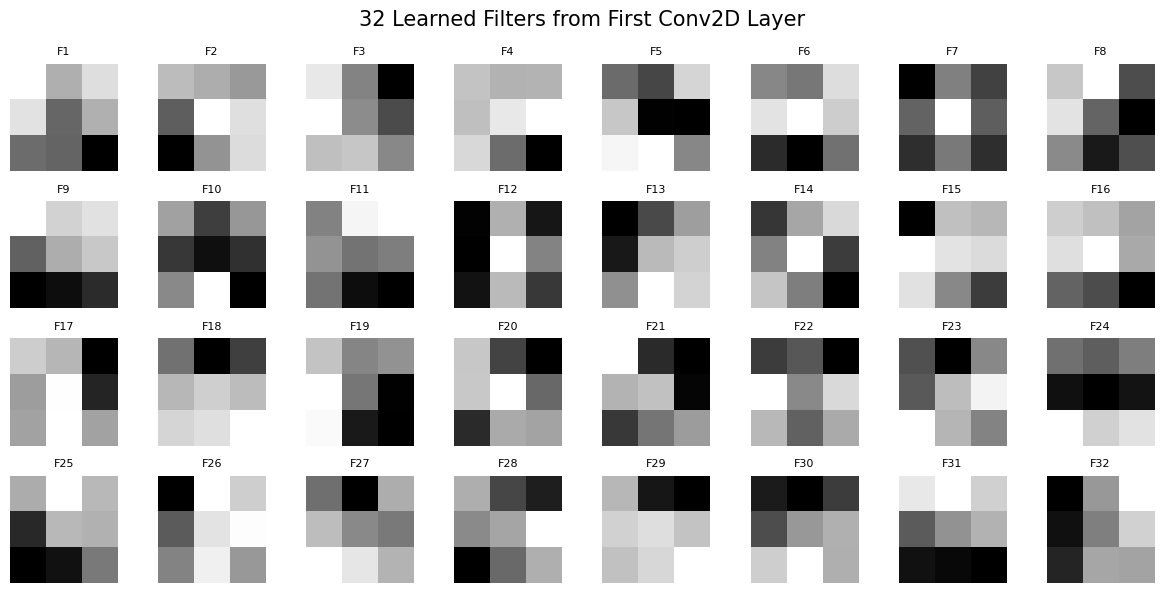

Selected Digit : 7


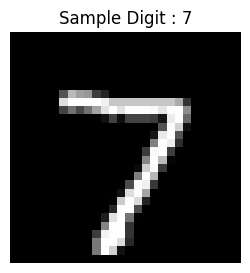

Generating Feature Maps from Conv Layer 1...
Feature Map Shape : (1, 28, 28, 32)


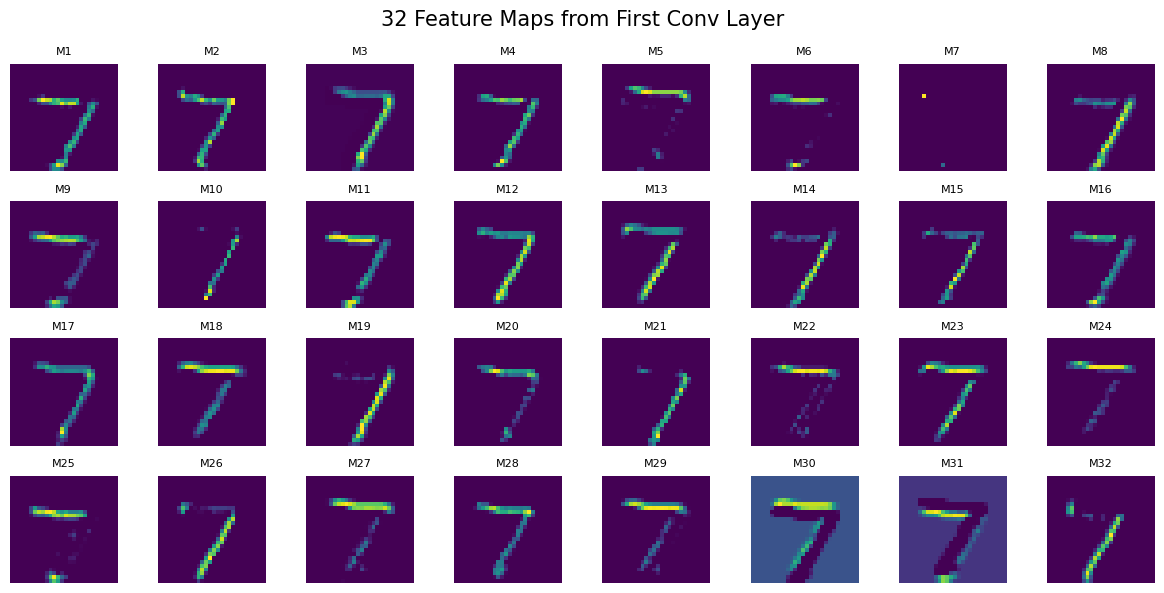

Comparing Layer 1 and Layer 2 Representations
Conv1 Output Shape : (1, 28, 28, 32)
Conv2 Output Shape : (1, 14, 14, 64)


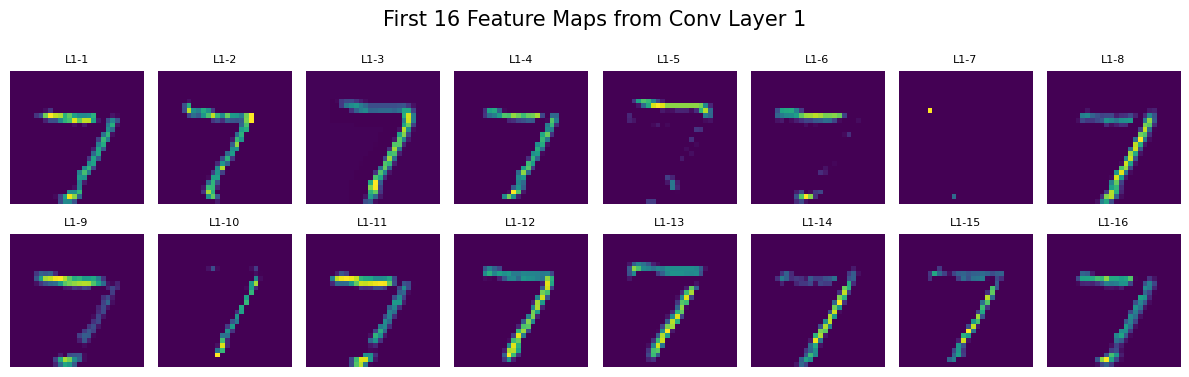

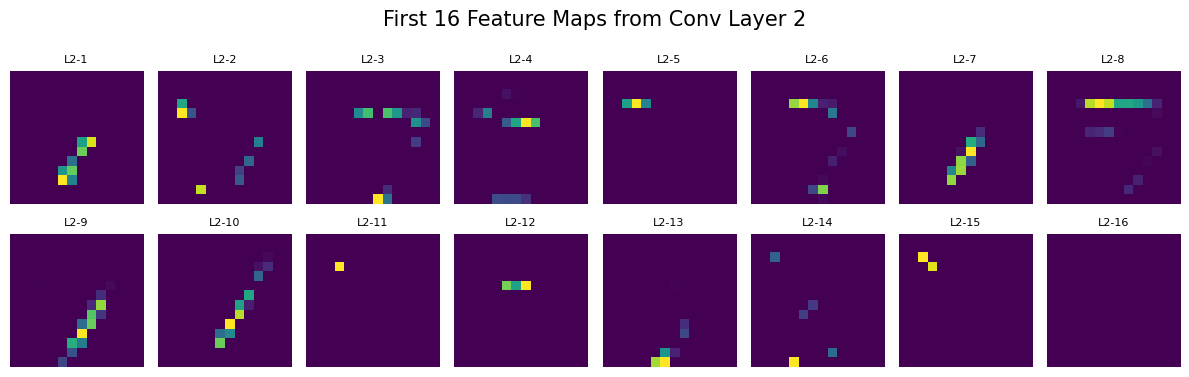

Observation:

1. The first convolution layer mainly captures simple edges, strokes, and local pixel patterns of the digit.
2. The second convolution layer combines these low-level features into more meaningful digit structures and shapes.
3. As we move deeper into the network, the representations become more abstract and discriminative, helping the model distinguish between different digit classes.

Part 3 Completed Successfully


In [ ]:
# Part 3 : What Does The Network See?

print("Visualizing Learned Filters...")                                          # Visualize Learned Filters from First Conv Layer
weights, biases = model.layers[0].get_weights()
print("Filter Weight Shape :", weights.shape)
fig, axes = plt.subplots(nrows=4, ncols=8, figsize=(12,6))

for i in range(32):
    filter_image = weights[:, :, 0, i]                                            # Normalize Filter to [0,1]
    filter_image = (filter_image - filter_image.min())/(filter_image.max()
        - filter_image.min()+ 1e-8)
    axes[i // 8, i % 8].imshow(filter_image,cmap="gray")
    axes[i // 8, i % 8].set_title(f"F{i+1}",fontsize=8)
    axes[i // 8, i % 8].axis("off")

plt.suptitle("32 Learned Filters from First Conv2D Layer",fontsize=15)
plt.tight_layout()
plt.show()


sample_index = 0                                                                 # Select One Test Image
sample_image = X_test[sample_index : sample_index + 1]
sample_label = y_test[sample_index]
print("Selected Digit :", sample_label)

plt.figure(figsize=(3,3))
plt.imshow(sample_image.squeeze(), cmap="gray")
plt.title(f"Sample Digit : {sample_label}")
plt.axis("off")
plt.show()


print("Generating Feature Maps from Conv Layer 1...")                            # Feature Maps from First Conv Layer
conv1_layer = model.layers[0]
feature_maps_conv1 = conv1_layer(sample_image).numpy()
print("Feature Map Shape :",feature_maps_conv1.shape)

fig, axes = plt.subplots(nrows=4, ncols=8, figsize=(12,6))
for i in range(32):
    fmap = feature_maps_conv1[0, :, :, i]
    fmap = (fmap - fmap.min())/(fmap.max()- fmap.min()+ 1e-8)
    axes[i // 8, i % 8].imshow(fmap, cmap="viridis")
    axes[i // 8, i % 8].axis("off")
    axes[i // 8, i % 8].set_title(f"M{i+1}",fontsize=8)

plt.suptitle("32 Feature Maps from First Conv Layer", fontsize=15)
plt.tight_layout()
plt.show()


print("Comparing Layer 1 and Layer 2 Representations")                           # Feature Maps from Conv Layer 1 and Conv Layer 2
conv1_output = model.layers[0](sample_image).numpy()                             # Conv Layer 1 Output
pool1_output = model.layers[1](conv1_output).numpy()                             # Conv1 + Pool1
conv2_output = model.layers[2](pool1_output).numpy()                             # Conv Layer 2 Output
print("Conv1 Output Shape :",conv1_output.shape)
print("Conv2 Output Shape :",conv2_output.shape)

fig, axes = plt.subplots(nrows=2, ncols=8, figsize=(12,4))                       # Display First 16 Feature Maps from Layer 1
for i in range(16):
    fmap = conv1_output[0, :, :, i]
    fmap = (fmap - fmap.min()) / (fmap.max()- fmap.min()+ 1e-8)
    axes[i // 8, i % 8].imshow(fmap, cmap="viridis")
    axes[i // 8, i % 8].axis("off")
    axes[i // 8, i % 8].set_title(f"L1-{i+1}", fontsize=8)
plt.suptitle("First 16 Feature Maps from Conv Layer 1", fontsize=15)
plt.tight_layout()
plt.show()


fig, axes = plt.subplots(nrows=2, ncols=8, figsize=(12,4))                       # Display First 16 Feature Maps from Layer 2
for i in range(16):
    fmap = conv2_output[0, :, :, i]
    fmap = (fmap - fmap.min()) / (fmap.max()- fmap.min()+ 1e-8)
    axes[i // 8, i % 8].imshow(fmap, cmap="viridis")
    axes[i // 8, i % 8].axis("off")
    axes[i // 8, i % 8].set_title(f"L2-{i+1}", fontsize=8)
plt.suptitle("First 16 Feature Maps from Conv Layer 2", fontsize=15)
plt.tight_layout()
plt.show()


print("Observation:\n")                                                            # Required Observation

print("1. The first convolution layer mainly captures simple edges, strokes, and local pixel patterns of the digit.")
print("2. The second convolution layer combines these low-level features into more meaningful digit structures and shapes.")
print("3. As we move deeper into the network, the representations become more abstract and discriminative, helping the model distinguish between different digit classes.")
print("\nPart 3 Completed Successfully")

Running Inference on Test Set...

Total Misclassified Images : 69


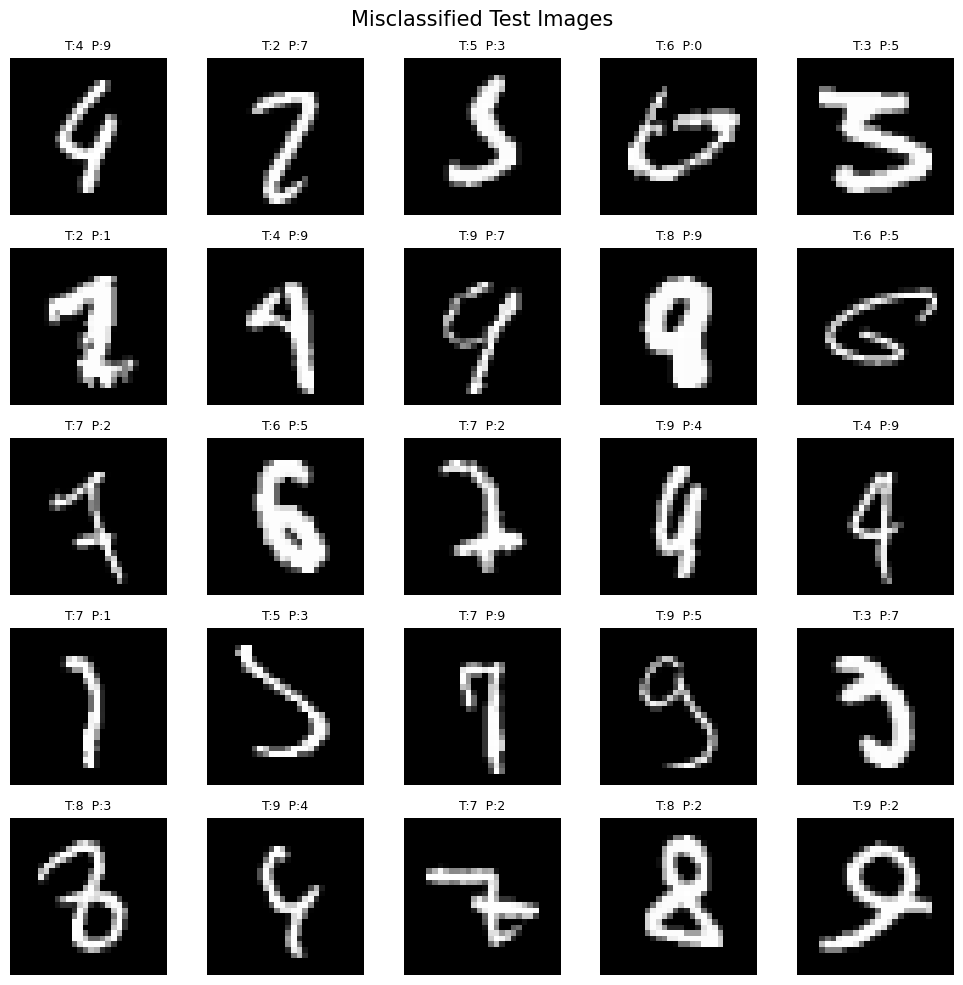

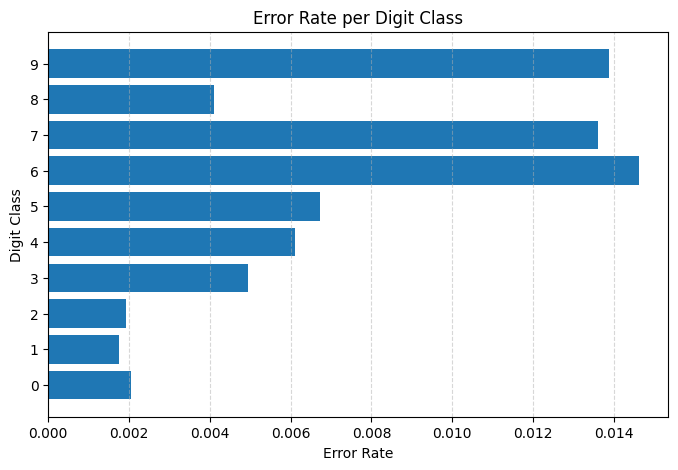


Hardest Digit Class : 6
Error Rate : 0.0146

Most Confused Pair
True Digit      : 4
Predicted Digit : 9
Confusion Count : 6


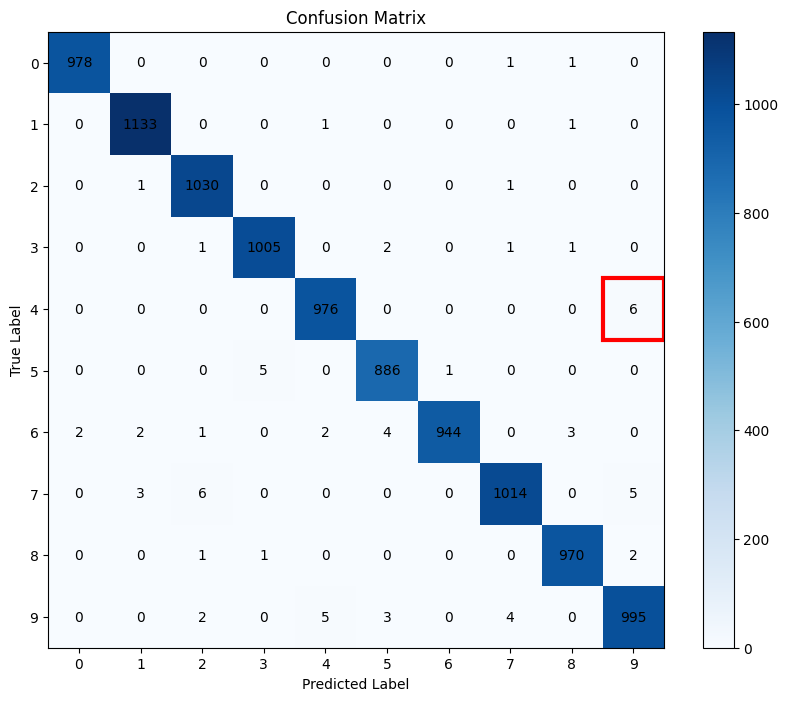

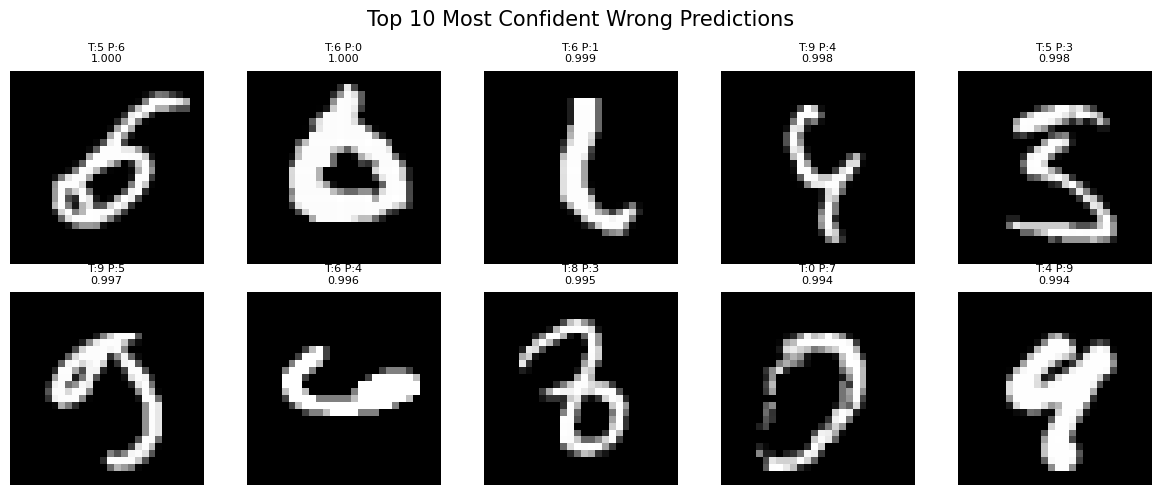


Top 10 Most Confident Wrong Predictions

1. True=5 | Predicted=6 | Confidence=0.9999
2. True=6 | Predicted=0 | Confidence=0.9999
3. True=6 | Predicted=1 | Confidence=0.9993
4. True=9 | Predicted=4 | Confidence=0.9981
5. True=5 | Predicted=3 | Confidence=0.9980
6. True=9 | Predicted=5 | Confidence=0.9974
7. True=6 | Predicted=4 | Confidence=0.9957
8. True=8 | Predicted=3 | Confidence=0.9947
9. True=0 | Predicted=7 | Confidence=0.9944
10. True=4 | Predicted=9 | Confidence=0.9942

Part 4 Completed Successfully


In [ ]:
# Part 4 : Error Analysis

print("Running Inference on Test Set...")                                        # Run Inference on Full Test Set
y_probabilities = model.predict(X_test, verbose=0)
y_predictions = np.argmax(y_probabilities, axis=1)


misclassified_indices = np.where(y_predictions != y_test)[0]                     # Collect Misclassified Images
print(f"\nTotal Misclassified Images : {len(misclassified_indices)}")


fig, axes = plt.subplots(5, 5, figsize=(10,10))                                  # Display 25 Misclassified Images
for i in range(25):
    idx = misclassified_indices[i]
    axes[i//5, i%5].imshow(X_test[idx].squeeze(), cmap='gray')
    axes[i//5, i%5].set_title(f"T:{y_test[idx]}  P:{y_predictions[idx]}",fontsize=9)
    axes[i//5, i%5].axis('off')
plt.suptitle("Misclassified Test Images", fontsize=15)
plt.tight_layout()
plt.show()


error_rates = []                                                                 # Error Rate Per Digit Class
for digit in range(10):
    total_samples = np.sum(y_test == digit)
    wrong_samples = np.sum((y_test == digit) &(y_predictions != digit))
    error_rate = wrong_samples / total_samples
    error_rates.append(error_rate)
error_rates = np.array(error_rates)


plt.figure(figsize=(8,5))                                                        # Horizontal Bar Chart
plt.barh(range(10), error_rates)
plt.yticks(range(10))
plt.xlabel("Error Rate")
plt.ylabel("Digit Class")
plt.title("Error Rate per Digit Class")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()


hardest_digit = np.argmax(error_rates)                                           # Hardest Digit
print(f"\nHardest Digit Class : {hardest_digit}")
print(f"Error Rate : {error_rates[hardest_digit]:.4f}")


cm = confusion_matrix(y_test, y_predictions)                                     # Confusion Matrix


cm_copy = cm.copy()                                                              # Find Most Confused Pair
np.fill_diagonal(cm_copy, 0)
max_position = np.unravel_index(np.argmax(cm_copy), cm_copy.shape)
true_digit = max_position[0]
pred_digit = max_position[1]
confusion_count = cm_copy[true_digit, pred_digit]
print("\nMost Confused Pair")
print(f"True Digit      : {true_digit}")
print(f"Predicted Digit : {pred_digit}")
print(f"Confusion Count : {confusion_count}")



plt.figure(figsize=(10,8))                                                       # Plot Confusion Matrix (Matplotlib Only)
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(np.arange(10))
plt.yticks(np.arange(10))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")


for i in range(cm.shape[0]):                                                     # Display Cell Values
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
            ha='center',
            va='center',
            color='black')


plt.gca().add_patch(plt.Rectangle(                                               # Highlight Most Confused Pair
        (pred_digit - 0.5, true_digit - 0.5),
        1, 1, fill=False,
        edgecolor='red',
        linewidth=3))
plt.show()


wrong_probabilities = y_probabilities[misclassified_indices]                     # Top 10 Most Confident Wrong Predictions
wrong_predictions = y_predictions[misclassified_indices]
wrong_truth = y_test[misclassified_indices]
confidence_scores = np.max(wrong_probabilities, axis=1)
top10_indices = np.argsort( confidence_scores)[::-1][:10]


fig, axes = plt.subplots(2, 5, figsize=(12,5))                                   # Display Top 10 Wrong Predictions
for i, idx_position in enumerate(top10_indices):
    actual_idx = misclassified_indices[idx_position]
    confidence = confidence_scores[idx_position]
    true_label = wrong_truth[idx_position]
    predicted_label = wrong_predictions[idx_position]
    axes[i//5, i%5].imshow(X_test[actual_idx].squeeze(), cmap='gray')
    axes[i//5, i%5].set_title(
        f"T:{true_label} P:{predicted_label}\n{confidence:.3f}", fontsize=8)
    axes[i//5, i%5].axis('off')
plt.suptitle("Top 10 Most Confident Wrong Predictions", fontsize=15)
plt.tight_layout()
plt.show()

print("\nTop 10 Most Confident Wrong Predictions\n")                             # Print Details
for rank, idx_position in enumerate(top10_indices):
    confidence = confidence_scores[idx_position]
    true_label = wrong_truth[idx_position]
    predicted_label = wrong_predictions[idx_position]
    print(f"{rank+1}. "
        f"True={true_label} | "
        f"Predicted={predicted_label} | "
        f"Confidence={confidence:.4f}")
print("\nPart 4 Completed Successfully")

In [ ]:
# Part 5 : LLM Post-Mortem Report

print("Collecting Model Performance Metrics...")                                # Collect Required Metrics


final_test_accuracy = test_accuracy                                             # Test Accuracy
f1_scores_dict = {}

for digit in range(10):
    f1_scores_dict[digit] = round(float(f1_per_class[digit]), 4)                # F1 Scores Per Digit
most_confused_pair = (int(true_digit), int(pred_digit))                         # Most Confused Pair


top3_error_digits = np.argsort(error_rates)[::-1][:3]                           # Top 3 Digits with Highest Error Rate
top3_error_digits = [int(x)
    for x in top3_error_digits]
print("\nTop 3 Error Digits :",top3_error_digits)


prompt = f"""                                                                   # Build Structured Prompt
Role:
You are an AI Model Auditor.
Task:
Analyze the performance of a CNN trained on the MNIST handwritten digit dataset.
Performance Metrics:
Test Accuracy:
{final_test_accuracy:.4f}
Per-Class F1 Scores:
{f1_scores_dict}
Most Confused Digit Pair:
Digit {most_confused_pair[0]} predicted as Digit {most_confused_pair[1]}
Top 3 Digits with Highest Error Rate:
{top3_error_digits}

Instructions:
Write a diagnostic report between 150 and 200 words.
The report should include:

1. Overall model quality and performance.
2. Which digit classes appear problematic and a possible reason why these digits are difficult.
3. Discussion of the most confused digit pair.
4. One concrete recommendation to improve the model accuracy further.

Write in a professional analyst style.
"""

client = OpenAI(                                                                # NVIDIA NIM Configuration
    base_url="https://integrate.api.nvidia.com/v1",
    api_key="nvapi-XXXXXXXXXXXXXXXXXXXXXXXXXXXXXxxxxxxx")


print("\nGenerating Analyst Report using NVIDIA NIM...")                        # Generate LLM Report
try:
    response = client.chat.completions.create(
        model="meta/llama-3.3-70b-instruct",
        messages=[{"role": "user", "content": prompt}], temperature=0.4,
        max_tokens=300)
    llm_report = (response.choices[0].message.content)

    print("LLM POST-MORTEM REPORT" )
    print(llm_report)

except Exception as e:
    print("\nNVIDIA API Error:")
    print(e)

print("\nPart 5 Completed Successfully")


Top 3 Error Digits : [6, 9, 7]

Generating Analyst Report using NVIDIA NIM...
LLM POST-MORTEM REPORT
Diagnostic Report: CNN Performance on MNIST Dataset

The CNN model demonstrates high-quality performance on the MNIST dataset, achieving a test accuracy of 0.9931. Per-class F1 scores indicate excellent performance across all digit classes, with scores above 0.98 for most classes. However, digits 6, 9, and 7 exhibit relatively higher error rates, suggesting potential difficulties in distinguishing these classes. A possible reason for this could be the similarity in writing styles or the presence of ambiguous samples.

The most confused digit pair, 4 predicted as 9, may be due to the visual similarity between these digits, particularly when written in certain styles. To improve model accuracy, we recommend collecting and incorporating additional training data that specifically targets these problematic classes and digit pairs. By doing so, the model can learn to better distinguish betwe